In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product

In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [3]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

## Load agent and decoder

In [21]:
def load_agent_and_env(checkpoint_path, task='cartpole-swingup'):
    """Load agent and environment with the specified checkpoint.
    
    Args:
        checkpoint_path: Path to the checkpoint file
        
    Returns:
        tuple: (agent, env, cfg) - loaded agent, environment, and config
    """
    # Base configuration
    override_cfg = dict(
        task=task,
        checkpoint=checkpoint_path,
        obs='state',
        seed=0,
        compile=False,
        mpc=True,
        multitask=False,
        model_size=5,
        save_video=False,  # Disable video to speed up sweep
        record_planning=False,  # Focus on episode data
    )

    with initialize(config_path="tdmpc2", version_base=None):
        cfg = compose(config_name="config")
        OmegaConf.set_struct(cfg, False)
        cfg = OmegaConf.merge(cfg, override_cfg)

    # Parse config
    cfg = parse_cfg(cfg)
    set_seed(cfg.seed)

    # cfg.initial_state = {
    #     'qpos': {
    #         'slider': 0,  #cart position
    #         'hinge_1': 0,  # pole angle
    #     },
    # }

    env = make_env(cfg)

    print("\nLoading agent...")
    agent = TDMPC2(cfg)

    # Optionally load checkpoint
    if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
        print(f"Loading checkpoint: {cfg.checkpoint}")
        agent.load(cfg.checkpoint)

    return agent, env

In [18]:
import pickle
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/decoder.pkl',
        'rb') as f:
    decoder = pickle.load(f)


In [10]:
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 1130.42it/s]


Found 108 configurations
Found 108 configurations


100%|██████████| 108/108 [00:00<00:00, 259.91it/s]


In [11]:
df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))

## Does training improve performance?

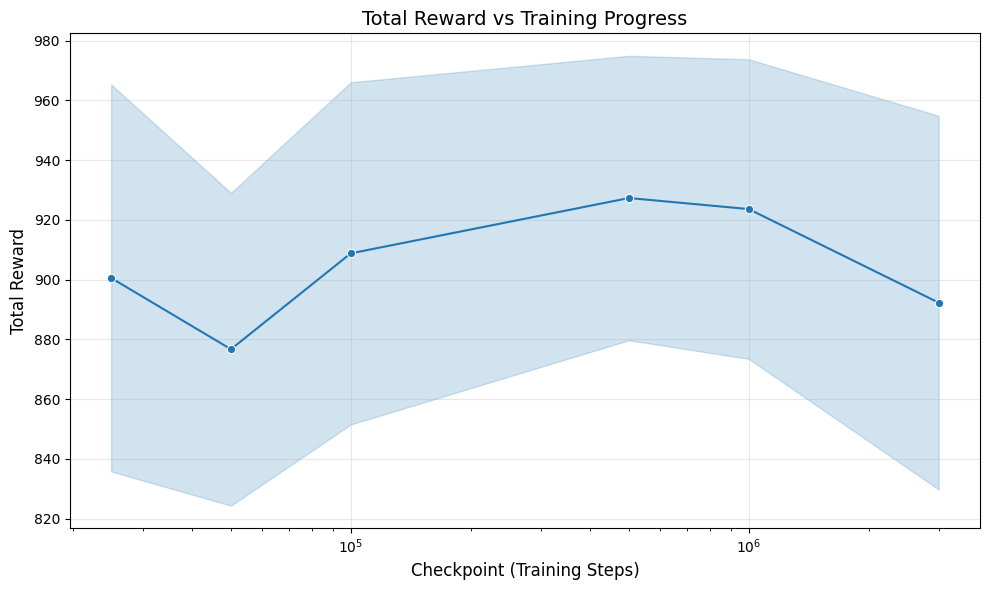

In [15]:
# Plot total reward vs checkpoint
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='ckpt_int', y='total_reward', marker='o', errorbar='sd')
plt.xscale('log')
plt.xlabel('Checkpoint (Training Steps)', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.title('Total Reward vs Training Progress', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Does training improve the accuracy of the dynamics model?

In [19]:
def run_env_autonomous(env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    #env.reset()
    obs_list = []
    obs_list.append(obs)
    for _ in range(n_steps - 1):
        next_obs, reward, done, info = env.step(torch.tensor([0.0]))
        obs_list.append(next_obs)

    return np.array(obs_list)


@torch.no_grad()
def run_dynamics_model(agent, env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    z = agent.model.encode(obs.to(agent.device), task=None)

    obs_list = []
    obs_list.append(obs)
    z_list = []
    z_list.append(z.cpu().numpy())
    for _ in range(n_steps - 1):
        #next_obs, *_ = env.step(torch.tensor([0.0]))

        z = agent.model.next(z, torch.tensor([0.0]).to(agent.device), task=None)
        z_list.append(z.cpu().numpy())
        #obs_list.append(next_obs)

    return np.array(z_list)

In [22]:
# Example usage:
CKPT_PATH = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt'

In [24]:
from pathlib import Path

MODELS_DIR = Path('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models')
MODEL_STEPS = [
    25_000,  # Early training
    50_000,  # Mid-early training
    100_000,  # Mid training
    500_000,  # Late training
    1_000_000,  # Near convergence
    3_000_000,  # Final checkpoint
]

# Get list of all model checkpoint paths
MODEL_PATHS = [MODELS_DIR / f"{step}.pt" for step in MODEL_STEPS]


In [25]:
MODEL_PATHS

[PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/25000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/50000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/100000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/1000000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/3000000.pt')]

In [49]:
initial_angles

array([  0.,  72., 144., 216., 288., 360.])

In [ ]:
intital_positions = [0]
initial_angles = np.array([36., 72., 144., 216., 288.])
steps_to_run = 50

results = {}

prod_list = list(product(intital_positions, initial_angles, MODEL_PATHS))
for initial_position, initial_angle, model_path in tqdm(prod_list):

    agent, env = load_agent_and_env(model_path)
    ckpt_int = int(str(model_path).split('/')[-1].split('.')[0])
    initial_angle_radians = np.radians(initial_angle)
    initial_state = {
        'qpos': {
            'slider': initial_position,  #cart position
            'hinge_1': initial_angle_radians,  # pole angle
        },
        'qvel': {
            'slider': 0,  #cart velocity
            'hinge_1': 0,  # pole angular velocity
        }
    }

    obs_true = run_env_autonomous(env, initial_state, steps_to_run)
    z_true = agent.model.encode(torch.from_numpy(obs_true).to(agent.device),
                                task=None).detach().cpu().numpy()

    z_predicted = run_dynamics_model(agent, env, initial_state, steps_to_run)
    obs_predicted = decoder.predict(z_predicted)

    # dict_results_steps = {}
    # for k in list(range(1, 10 + 1)) + [50]:
    #     z_predicted_steps, obs_true_steps = run_dynamics_model_in_steps(
    #         agent, env, initial_state, n_steps=steps_to_run, k=k)
    #     obs_predicted_steps = decoder.predict(z_predicted_steps)
    #     dict_results_steps[f'z_predicted_steps_{k}'] = z_predicted_steps
    #     #dict_results_steps[f'obs_true_steps_{k}'] = obs_true_steps
    #     dict_results_steps[f'obs_predicted_steps_{k}'] = obs_predicted_steps

    errors_latent = ((z_true - z_predicted)**2).mean(1)
    errors_physical = ((obs_true - obs_predicted)**2).mean(1)
    error_physical_per_dim = [
        ((obs_true[:, i] - obs_predicted[:, i])**2).mean() for i in range(5)
    ]
    error_latent_per_dim = [
        ((z_true[:, i] - z_predicted[:, i])**2).mean() for i in range(512)
    ]
    r2_physical = r2_score(obs_true, obs_predicted)
    r2_physical_per_dim = [
        r2_score(obs_true[:, i], obs_predicted[:, i]) for i in range(5)
    ]
    r2_latent = r2_score(z_true, z_predicted)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_predicted, axis=0)

    results[(ckpt_int, initial_position, initial_angle)] = {
        'obs_true': obs_true,
        'obs_predicted': obs_predicted,
        'z_true': z_true,
        'z_predicted': z_predicted,
        'errors_latent': errors_latent,
        'errors_physical': errors_physical,
        'error_physical_per_dim': error_physical_per_dim,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_physical': r2_physical,
        'r2_physical_per_dim': r2_physical_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
    }

In [51]:
results.keys()

dict_keys([(25000, 0, 36.0), (50000, 0, 36.0), (100000, 0, 36.0), (500000, 0, 36.0), (1000000, 0, 36.0), (3000000, 0, 36.0), (25000, 0, 72.0), (50000, 0, 72.0), (100000, 0, 72.0), (500000, 0, 72.0), (1000000, 0, 72.0), (3000000, 0, 72.0), (25000, 0, 144.0), (50000, 0, 144.0), (100000, 0, 144.0), (500000, 0, 144.0), (1000000, 0, 144.0), (3000000, 0, 144.0), (25000, 0, 216.0), (50000, 0, 216.0), (100000, 0, 216.0), (500000, 0, 216.0), (1000000, 0, 216.0), (3000000, 0, 216.0), (25000, 0, 288.0), (50000, 0, 288.0), (100000, 0, 288.0), (500000, 0, 288.0), (1000000, 0, 288.0), (3000000, 0, 288.0)])

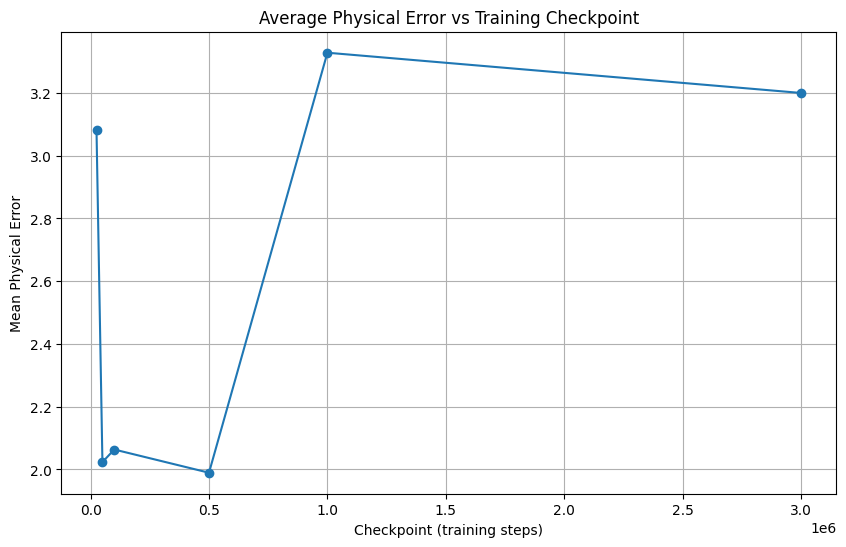

In [52]:
# Compute average error_physical for each checkpoint
ckpt_errors = {}
for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    if ckpt_int not in ckpt_errors:
        ckpt_errors[ckpt_int] = []
    ckpt_errors[ckpt_int].append(results[key]['errors_physical'].mean())

# Compute mean error for each checkpoint
ckpt_mean_errors = {
    ckpt: np.mean(errors) for ckpt, errors in ckpt_errors.items()
}

# Sort by checkpoint for plotting
ckpts = sorted(ckpt_mean_errors.keys())
mean_errors = [ckpt_mean_errors[ckpt] for ckpt in ckpts]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(ckpts, mean_errors, marker='o')
plt.xlabel('Checkpoint (training steps)')
plt.ylabel('Mean Physical Error')
plt.title('Average Physical Error vs Training Checkpoint')
plt.grid(True)
plt.show()

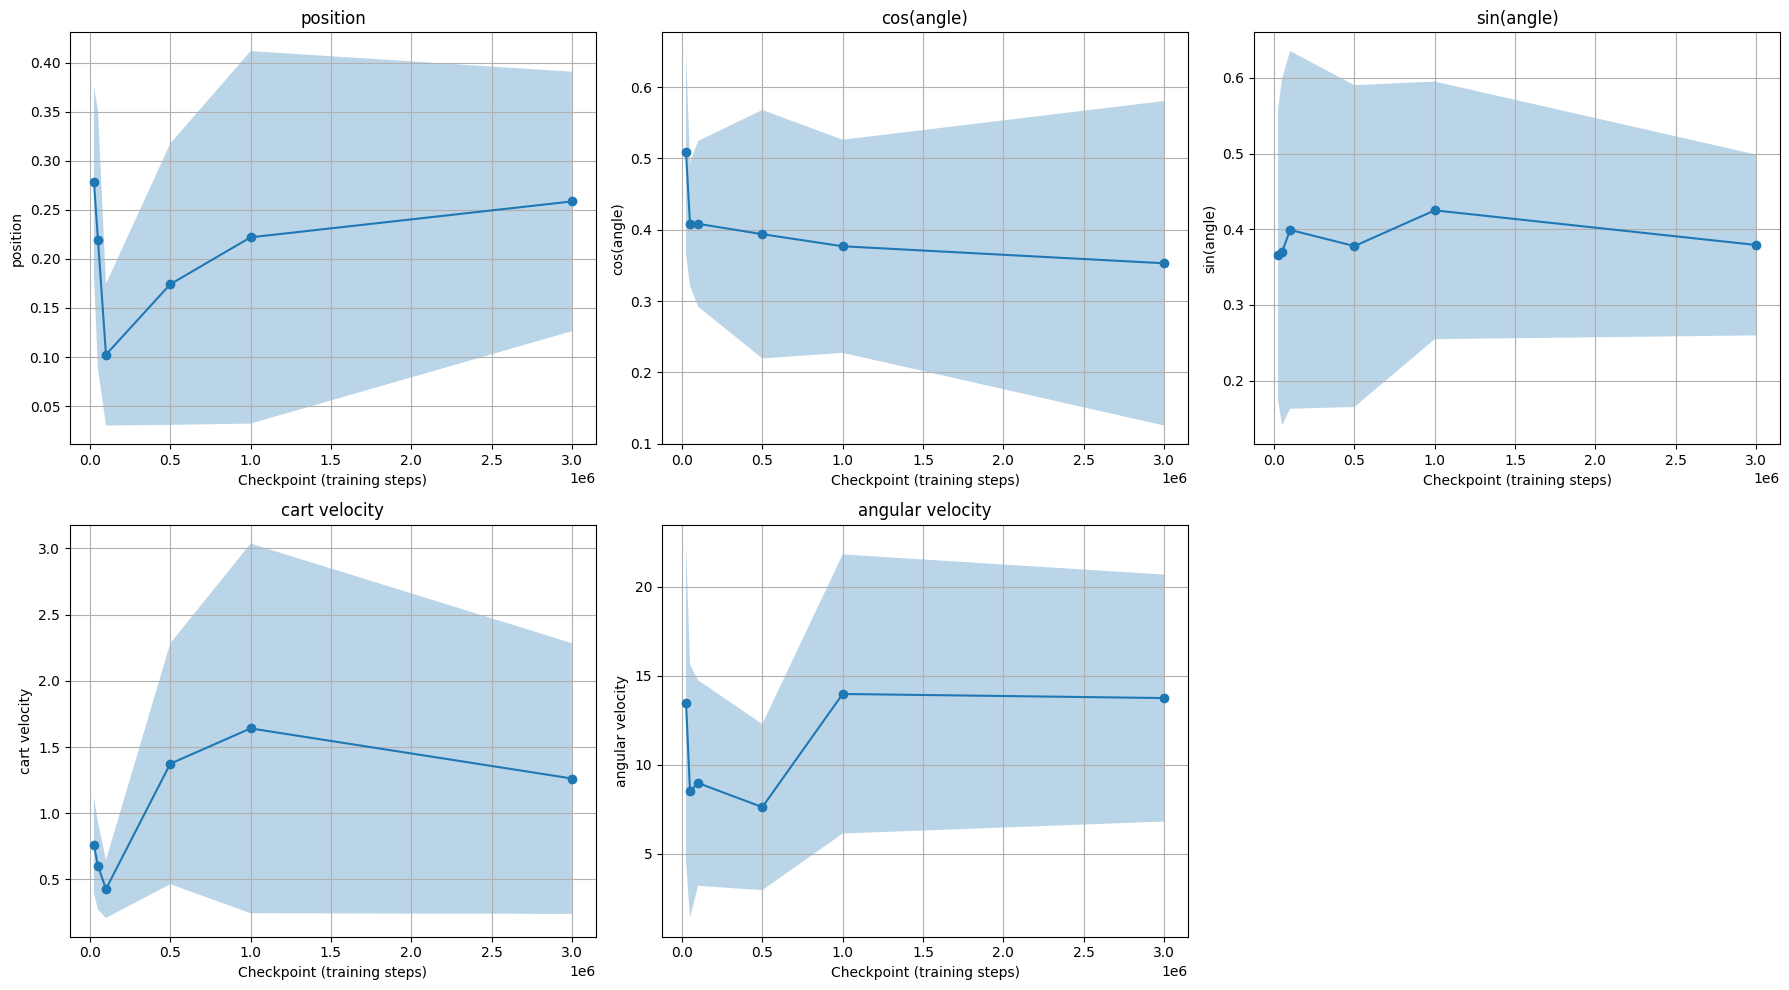

In [58]:
# Plot error_physical_per_dim for each dimension across checkpoints
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

# Collect errors per dimension for each checkpoint
ckpt_errors_per_dim = {}
for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    if ckpt_int not in ckpt_errors_per_dim:
        ckpt_errors_per_dim[ckpt_int] = {dim: [] for dim in range(5)}

    error_per_dim = results[key]['error_physical_per_dim']
    for dim in range(5):
        ckpt_errors_per_dim[ckpt_int][dim].append(error_per_dim[dim])

# Compute mean and std error per dimension for each checkpoint
ckpt_mean_errors_per_dim = {}
ckpt_std_errors_per_dim = {}
for ckpt in ckpt_errors_per_dim.keys():
    ckpt_mean_errors_per_dim[ckpt] = {
        dim: np.mean(ckpt_errors_per_dim[ckpt][dim]) for dim in range(5)
    }
    ckpt_std_errors_per_dim[ckpt] = {
        dim: np.std(ckpt_errors_per_dim[ckpt][dim]) for dim in range(5)
    }

# Sort checkpoints for plotting
ckpts = sorted(ckpt_mean_errors_per_dim.keys())

# Create subplots with 3 plots per row
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for dim in range(5):
    mean_errors_dim = [ckpt_mean_errors_per_dim[ckpt][dim] for ckpt in ckpts]
    std_errors_dim = [ckpt_std_errors_per_dim[ckpt][dim] for ckpt in ckpts]

    axes[dim].plot(ckpts, mean_errors_dim, marker='o')
    axes[dim].fill_between(ckpts,
                           np.array(mean_errors_dim) - np.array(std_errors_dim),
                           np.array(mean_errors_dim) + np.array(std_errors_dim),
                           alpha=0.3)
    axes[dim].set_xlabel('Checkpoint (training steps)')
    axes[dim].set_ylabel(f'{variable_names[dim]}')
    axes[dim].set_title(f'{variable_names[dim]}')
    axes[dim].grid(True)

# Hide the last unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

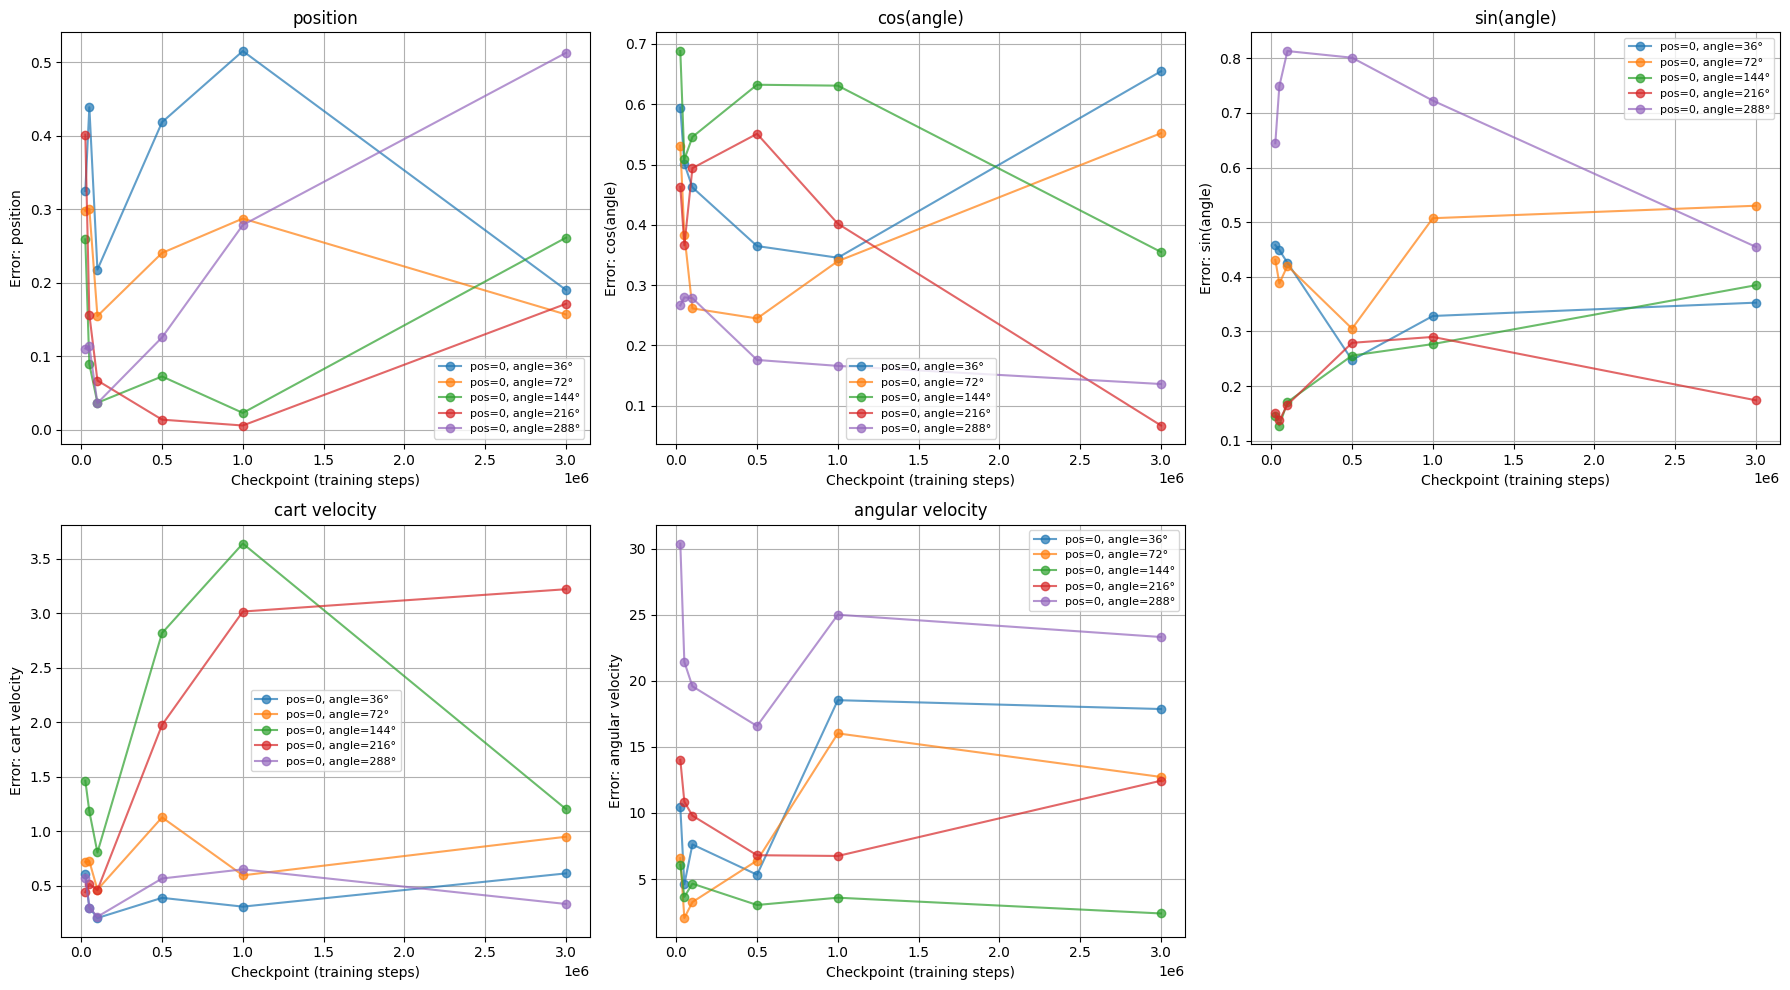

In [56]:
# Plot error_physical_per_dim for each dimension across checkpoints
# One plot per variable, with separate lines for each initial condition
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

# Collect errors per dimension for each checkpoint and initial condition
ckpt_errors_per_dim_per_init = {}
for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    init_condition = (initial_position, initial_angle)

    if ckpt_int not in ckpt_errors_per_dim_per_init:
        ckpt_errors_per_dim_per_init[ckpt_int] = {}

    if init_condition not in ckpt_errors_per_dim_per_init[ckpt_int]:
        ckpt_errors_per_dim_per_init[ckpt_int][init_condition] = {
            dim: [] for dim in range(5)
        }

    error_per_dim = results[key]['error_physical_per_dim']
    for dim in range(5):
        ckpt_errors_per_dim_per_init[ckpt_int][init_condition][dim].append(
            error_per_dim[dim])

# Get all unique initial conditions
all_init_conditions = set()
for ckpt_data in ckpt_errors_per_dim_per_init.values():
    all_init_conditions.update(ckpt_data.keys())
all_init_conditions = sorted(all_init_conditions)

# Sort checkpoints for plotting
ckpts = sorted(ckpt_errors_per_dim_per_init.keys())

# Create subplots with 3 plots per row
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for dim in range(5):
    # Plot a line for each initial condition
    for init_condition in all_init_conditions:
        errors_for_init = []
        for ckpt in ckpts:
            if init_condition in ckpt_errors_per_dim_per_init[ckpt]:
                # Average over multiple runs with same initial condition (if any)
                errors = ckpt_errors_per_dim_per_init[ckpt][init_condition][dim]
                errors_for_init.append(np.mean(errors))
            else:
                errors_for_init.append(np.nan)

        label = f'pos={init_condition[0]:.0f}, angle={init_condition[1]:.0f}°'
        axes[dim].plot(ckpts,
                       errors_for_init,
                       marker='o',
                       alpha=0.7,
                       label=label)

    axes[dim].set_xlabel('Checkpoint (training steps)')
    axes[dim].set_ylabel(f'Error: {variable_names[dim]}')
    axes[dim].set_title(f'{variable_names[dim]}')
    axes[dim].grid(True)
    axes[dim].legend(fontsize=8, loc='best')

# Hide the last unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()